# Model Order Estimation

### Jimmy Jamison

This notebook explores the problem of model order estimation to determine the number of signal components in a TDOA response. This is a crucial preprocessing step to compute a super resolution TDOA response using MUSIC,

The problem of estimating the number of signal components in a TDOA response, is similar to estimating the number of incident signals on an antenna array in MUSIC for direction finding, but there are two factors making this problem more difficult:
1. Here the multiple incident signals are from multipath components and therefore highly correlated, so the covariance matrix is ill formed for directly applying AIC/MDL.
2. The matrix dimensions here are proportional (i.e. $M=2*N - 1$) to the length of the signal vector and can be quite large, where as in the DF problem they are equal to the number of antenna elements. The large matrices lead to issues computing and seperating the eigenvalues.

In the cells below, we try to estimate model order using AIC and MDL, both with and without diagonal loading of the eigenvalues. The estimates of $k$ are:

1. $k_{est_1}$ -> AIC
2. $k_{est_2}$ -> AIC with diagonal loading
3. $k_{est_3}$ -> MDL
4. $k_{est_4}$ -> MDL with diagonal loading

This is tested below for the same two scenarios used in `music_paper.ipynb` 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

num_samples: 500



Scenario 1
Size of R: (999, 999)
True k: 1 k_est1: 14 k_est2: 5 k_est3: 5 k_est4: 4
Size of R: (999, 999)
True k: 2 k_est1: 10 k_est2: 4 k_est3: 4 k_est4: 4
Size of R: (999, 999)
True k: 2 k_est1: 18 k_est2: 7 k_est3: 7 k_est4: 4
Size of R: (999, 999)
True k: 4 k_est1: 15 k_est2: 6 k_est3: 5 k_est4: 4

Scenario 2
Size of R: (999, 999)
True k: 1 k_est1: 20 k_est2: 4 k_est3: 4 k_est4: 3
Size of R: (999, 999)
True k: 2 k_est1: 19 k_est2: 4 k_est3: 4 k_est4: 3
Size of R: (999, 999)
True k: 2 k_est1: 11 k_est2: 5 k_est3: 5 k_est4: 5
Size of R: (999, 999)
True k: 4 k_est1: 14 k_est2: 6 k_est3: 6 k_est4: 5


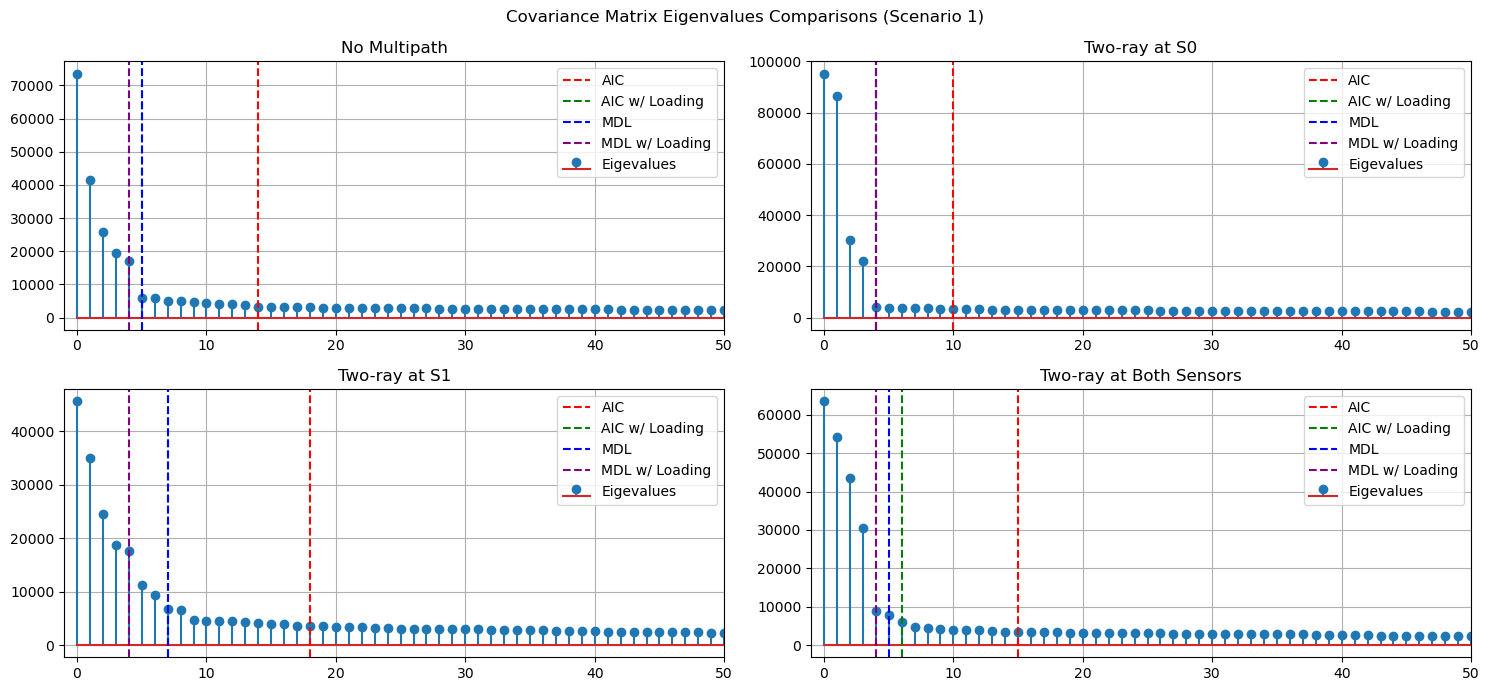

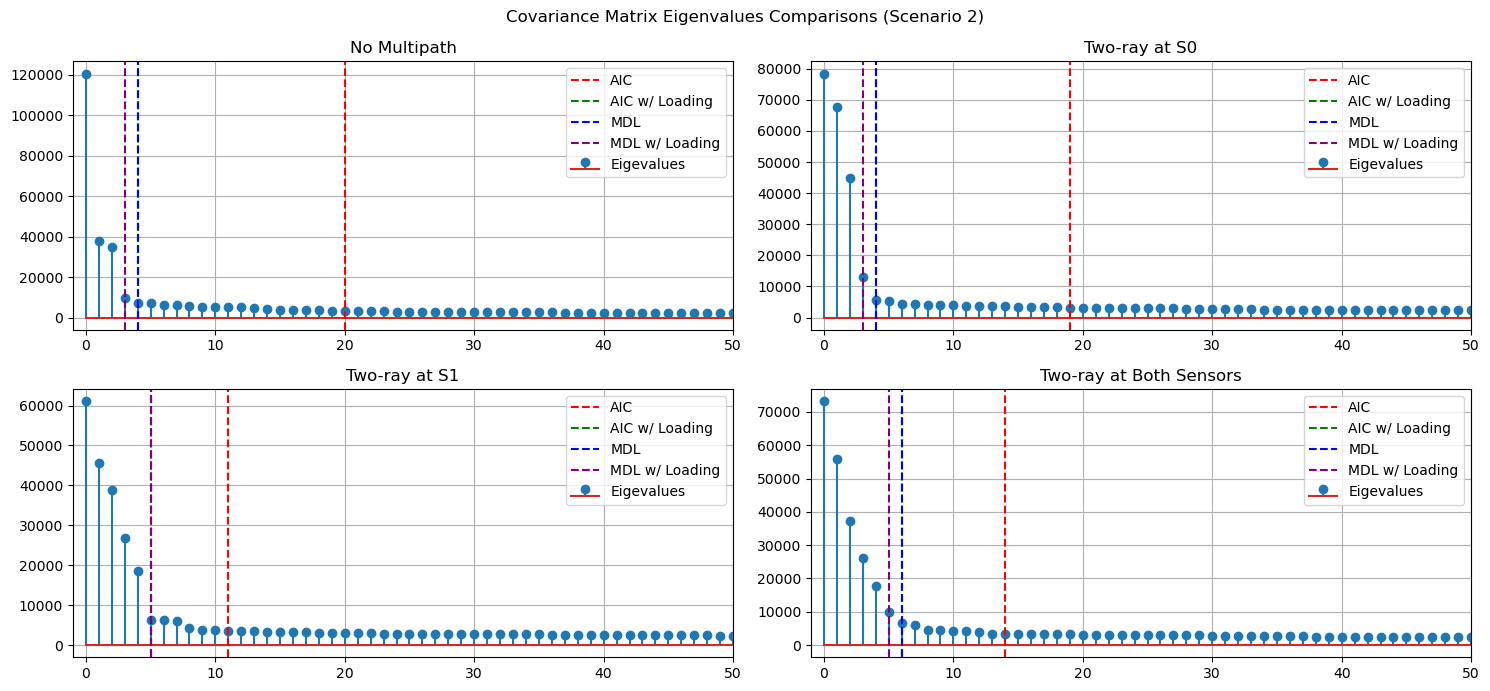

In [3]:
# TOAs from Scenario 1
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 19], [65]],
    'Two-ray at S1' : [[20], [65, 70]],
    'Two-ray at Both Sensors' : [[20, 19], [65, 70]]
}

print("\nScenario 1")

plt.figure(figsize=(15,7))
plt.suptitle(f"Covariance Matrix Eigenvalues Comparisons (Scenario 1)")

pltnum = 1
for desc, (toas0, toas1) in cases.items():

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    R = utils.normalized_cross_spec_covariance_mat(y0, y1)

    print(f"Size of R: {R.shape}")

    evals, _ = np.linalg.eig(R)
    sevals = np.sort(np.abs(evals))[::-1]
    k_est1 = utils.AIC(sevals)
    k_est2 = utils.AIC(sevals + np.mean(sevals))
    k_est3 = utils.MDL(sevals)
    k_est4 = utils.MDL(sevals + np.mean(sevals))

    print(f"True k: {len(true_tdoas)} k_est1: {k_est1} k_est2: {k_est2} k_est3: {k_est3} k_est4: {k_est4}")

    plt.subplot(2,2,pltnum)
    plt.title(desc)
    plt.stem(sevals, label='Eigevalues')
    plt.xlim([-1, 50])
    plt.grid()
    plt.axvline(x=k_est1, color='red', linestyle='--', label='AIC')
    plt.axvline(x=k_est2, color='green', linestyle='--', label='AIC w/ Loading')
    plt.axvline(x=k_est3, color='blue', linestyle='--', label='MDL')
    plt.axvline(x=k_est4, color='purple', linestyle='--', label='MDL w/ Loading')
    plt.legend()

    pltnum += 1

plt.tight_layout()

# TOAs from Scenario 2
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 18], [65]],
    'Two-ray at S1' : [[20], [67, 70]],
    'Two-ray at Both Sensors' : [[20, 18], [67, 70]]
}

print("\nScenario 2")

plt.figure(figsize=(15,7))
plt.suptitle(f"Covariance Matrix Eigenvalues Comparisons (Scenario 2)")

pltnum = 1
for desc, (toas0, toas1) in cases.items():

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    R = utils.normalized_cross_spec_covariance_mat(y0, y1)

    print(f"Size of R: {R.shape}")

    evals, _ = np.linalg.eig(R)
    sevals = np.sort(np.abs(evals))[::-1]
    k_est1 = utils.AIC(sevals)
    k_est2 = utils.AIC(sevals + np.mean(sevals))
    k_est3 = utils.MDL(sevals)
    k_est4 = utils.MDL(sevals + np.mean(sevals))

    print(f"True k: {len(true_tdoas)} k_est1: {k_est1} k_est2: {k_est2} k_est3: {k_est3} k_est4: {k_est4}")

    plt.subplot(2,2,pltnum)
    plt.title(desc)
    plt.stem(sevals, label='Eigevalues')
    plt.xlim([-1, 50])
    plt.grid()
    plt.axvline(x=k_est1, color='red', linestyle='--', label='AIC')
    plt.axvline(x=k_est2, color='green', linestyle='--', label='AIC w/ Loading')
    plt.axvline(x=k_est3, color='blue', linestyle='--', label='MDL')
    plt.axvline(x=k_est4, color='purple', linestyle='--', label='MDL w/ Loading')
    plt.legend()

    pltnum += 1

plt.tight_layout()

# Overlapping Blocks for Model Order Estimation

It can be seen in the plots above that there is not a clear seperation between signal and noise eigenvalues, and the eigenvalues fall off gradually between the signal and noise components. This makes it difficult for AIC and MDL to properly estimate $k$.

This is a similar problem to the problem of estimating DOA with MUSIC when receiving multiple highly correlated signals. One way to mitigate this in the DOA case is through "spatial smoothing" where an antenna array is seperated into symmetric sub-arrays, and covariance matrices are computed for each sub-array then averaged together to form the "smoothed" matrix used by MUSIC. Here I tried to mitigate the issue the issue simlarily for TDOA by computing covariance matrices over overlapping slices of the data from sensors 1 and 2. The hope was this would mitigate both issues mentioned earlier by reducing the dimension of $R$, and the effects of the correlated signals on the span of the noise space.

In [4]:
from typing import Any

Any1D = np.ndarray[tuple[int], np.dtype[Any]]
Any2D = np.ndarray[tuple[int,int], np.dtype[Any]]

# TODO: move to utils.py
def overlapping_windows(data: Any1D, window_size: int, overlap: int) -> Any2D:
    """
    Generates overlapping sliding windows from a 1D numpy array.

    Args:
        data: The input 1D array.
        window_size: The size of the sliding window.
        overlap: The number of elements to overlap between consecutive windows.

    Returns:
        A 2D array where each row is a window.
    """
    step = window_size - overlap
    return np.lib.stride_tricks.sliding_window_view(data, window_shape=window_size)[::step]


Scenario 1
Size of R: (399, 399)
True k: 1 k_est1: 8 k_est2: 2 k_est3: 1 k_est4: 0
Size of R: (399, 399)
True k: 2 k_est1: 9 k_est2: 4 k_est3: 4 k_est4: 1
Size of R: (399, 399)
True k: 2 k_est1: 8 k_est2: 4 k_est3: 4 k_est4: 2
Size of R: (399, 399)
True k: 4 k_est1: 14 k_est2: 7 k_est3: 7 k_est4: 2

Scenario 2
Size of R: (399, 399)
True k: 1 k_est1: 7 k_est2: 2 k_est3: 2 k_est4: 0
Size of R: (399, 399)
True k: 2 k_est1: 10 k_est2: 4 k_est3: 4 k_est4: 1
Size of R: (399, 399)
True k: 2 k_est1: 14 k_est2: 2 k_est3: 2 k_est4: 2
Size of R: (399, 399)
True k: 4 k_est1: 13 k_est2: 6 k_est3: 6 k_est4: 2


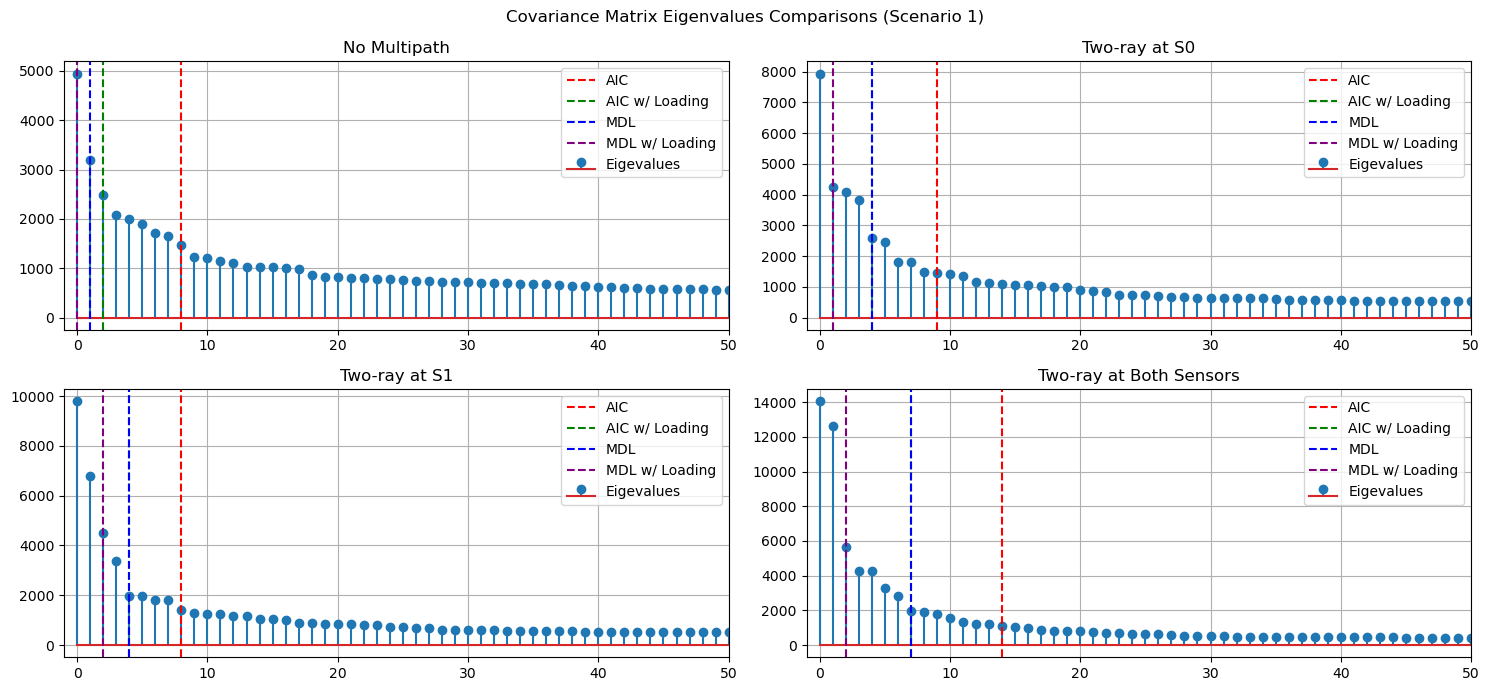

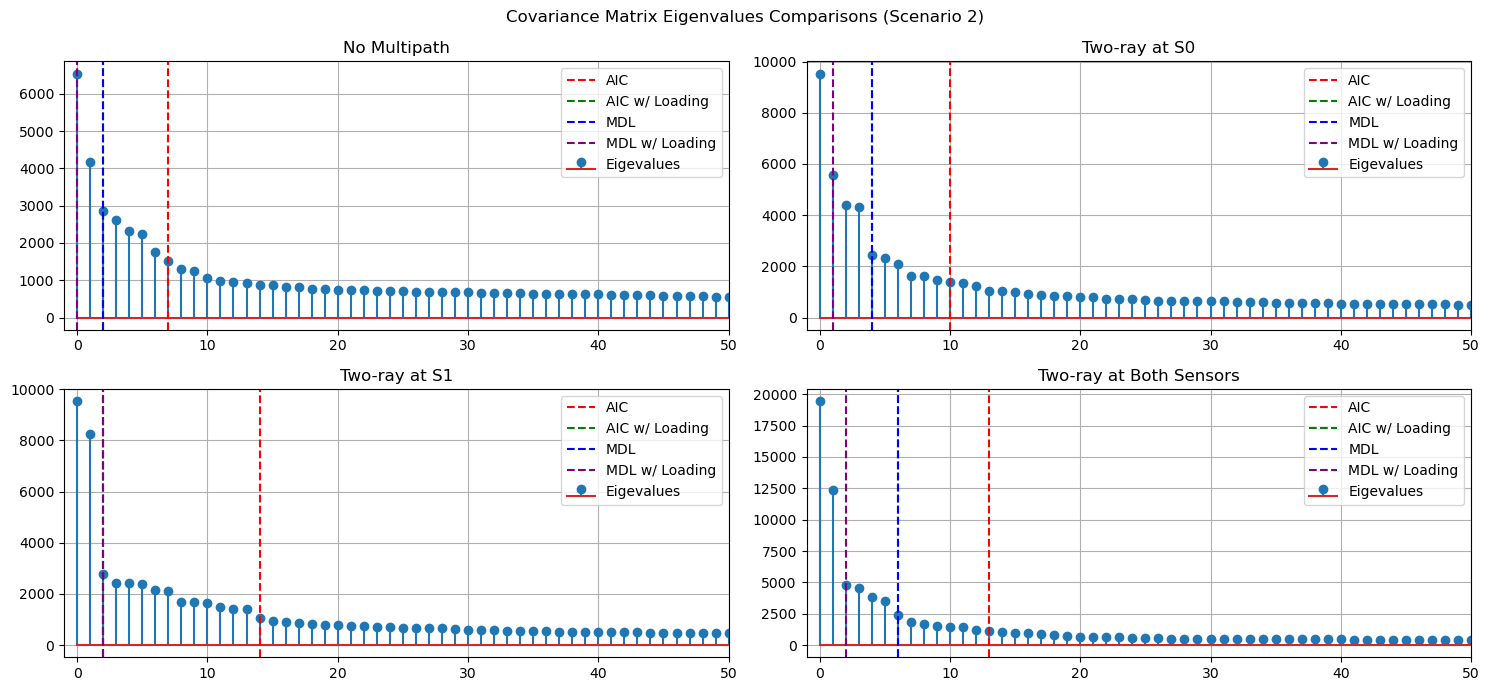

In [5]:
# TOAs from Scenario 1
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 19], [65]],
    'Two-ray at S1' : [[20], [65, 70]],
    'Two-ray at Both Sensors' : [[20, 19], [65, 70]]
}

print("\nScenario 1")

plt.figure(figsize=(15,7))
plt.suptitle(f"Covariance Matrix Eigenvalues Comparisons (Scenario 1)")

window = 200
overlap = 125

pltnum = 1
for desc, (toas0, toas1) in cases.items():

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    # Compute covariance matrix on overlapping intervals
    wy0 = overlapping_windows(y0, window, overlap)
    wy1 = overlapping_windows(y1, window, overlap)
    M = 2*wy0.shape[1]-1
    R = np.zeros((wy0.shape[0], M, M), dtype=np.complex128)
    for ix in range(R.shape[0]):

        y0_ = wy0[ix]
        y1_ = wy1[ix]
        R[ix] = utils.normalized_cross_spec_covariance_mat(y0_, y1_)

    R = R.mean(axis=0)

    print(f"Size of R: {R.shape}")

    evals, _ = np.linalg.eig(R)
    sevals = np.sort(np.abs(evals))[::-1]
    k_est1 = utils.AIC(sevals)
    k_est2 = utils.AIC(sevals + np.mean(sevals))
    k_est3 = utils.MDL(sevals)
    k_est4 = utils.MDL(sevals + np.mean(sevals))

    print(f"True k: {len(true_tdoas)} k_est1: {k_est1} k_est2: {k_est2} k_est3: {k_est3} k_est4: {k_est4}")

    plt.subplot(2,2,pltnum)
    plt.title(desc)
    plt.stem(sevals, label='Eigevalues')
    plt.xlim([-1, 50])
    plt.grid()
    plt.axvline(x=k_est1, color='red', linestyle='--', label='AIC')
    plt.axvline(x=k_est2, color='green', linestyle='--', label='AIC w/ Loading')
    plt.axvline(x=k_est3, color='blue', linestyle='--', label='MDL')
    plt.axvline(x=k_est4, color='purple', linestyle='--', label='MDL w/ Loading')
    plt.legend()

    pltnum += 1

plt.tight_layout()

# TOAs from Scenario 2
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 18], [65]],
    'Two-ray at S1' : [[20], [67, 70]],
    'Two-ray at Both Sensors' : [[20, 18], [67, 70]]
}

print("\nScenario 2")

plt.figure(figsize=(15,7))
plt.suptitle(f"Covariance Matrix Eigenvalues Comparisons (Scenario 2)")

pltnum = 1
for desc, (toas0, toas1) in cases.items():

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    # Compute covariance matrix on overlapping intervals
    wy0 = overlapping_windows(y0, window, overlap)
    wy1 = overlapping_windows(y1, window, overlap)
    M = 2*wy0.shape[1]-1
    R = np.zeros((wy0.shape[0], M, M), dtype=np.complex128)
    for ix in range(R.shape[0]):

        y0_ = wy0[ix]
        y1_ = wy1[ix]
        R[ix] = utils.normalized_cross_spec_covariance_mat(y0_, y1_)

    R = R.mean(axis=0)

    print(f"Size of R: {R.shape}")

    evals, _ = np.linalg.eig(R)
    sevals = np.sort(np.abs(evals))[::-1]
    k_est1 = utils.AIC(sevals)
    k_est2 = utils.AIC(sevals + np.mean(sevals))
    k_est3 = utils.MDL(sevals)
    k_est4 = utils.MDL(sevals + np.mean(sevals))

    print(f"True k: {len(true_tdoas)} k_est1: {k_est1} k_est2: {k_est2} k_est3: {k_est3} k_est4: {k_est4}")

    plt.subplot(2,2,pltnum)
    plt.title(desc)
    plt.stem(sevals, label='Eigevalues')
    plt.xlim([-1, 50])
    plt.grid()
    plt.axvline(x=k_est1, color='red', linestyle='--', label='AIC')
    plt.axvline(x=k_est2, color='green', linestyle='--', label='AIC w/ Loading')
    plt.axvline(x=k_est3, color='blue', linestyle='--', label='MDL')
    plt.axvline(x=k_est4, color='purple', linestyle='--', label='MDL w/ Loading')
    plt.legend()

    pltnum += 1

plt.tight_layout()